# Profiling Academic Trajectories: A ML Exploration of Student Performance

*Jairik "JJ" McCauley*

---

## Introduction

The Higher Education Students Performance Evaluation dataset [1] contains a mix of demographic, socioeconomic, academic, and behavioral attributes collected from students. Due to the wide array of features (32 in total), there is an immense amount of flexibility for analysis and exploration. Understanding what influences student performance has implications for advising, resource allocation, and instructional design within higher education.

In this project, I aim to identify different clusters of students, apply classification models to predict GPA categories, and gain insight into how individual features may impact perceived preparation and interest in a chosen field. These analyses enable exploration of not only predictive performance, but also broader patterns that may support student success and institutional planning.

[1]: Yilmaz, N. & Şekeroğlu, B. (2019). Higher Education Students Performance Evaluation [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C51G82


---

In [ ]:
# Initializing the environment and installing necessary libraries
%pip install numpy==1.26.4  # Specific numpy version for SHAP compatibility
%pip install plotly
%pip install shap==0.42.1  # SHAP library for interpretability analysis, specific version for compatibility
%pip install scikit-learn
%pip install pandas
%pip install matplotlib
%pip install ucimlrepo

## Data Exploration

Within the following sections, we will be understanding the features of the dataset, describing it using scientific methods, wrangling it for clean analysis, and observing feature relationships.

### Understanding the Dataset

Prior to diving into this large dataset, it is important to understand the overall structure with each feature and type in the dataset:

| #  | Feature                              | Type                                  |
| -- | ------------------------------------ | ------------------------------------- |
| 1  | Student Age                          | Categorical (ordinal)                 |
| 2  | Sex                                  | Binary                                |
| 3  | Graduated High-School Type           | Categorical                           |
| 4  | Scholarship Type                     | Categorical (ordinal)                 |
| 5  | Additional Work                      | Binary                                |
| 6  | Artistic/Sports Activity             | Binary                                |
| 7  | Has a Partner                        | Binary                                |
| 8  | Total Salary                         | Categorical (ordinal)                 |
| 9  | Transportation Mode                  | Categorical                           |
| 10 | Accommodation Type                   | Categorical                           |
| 11 | Mother’s Education                   | Categorical (ordinal)                 |
| 12 | Father’s Education                   | Categorical (ordinal)                 |
| 13 | Number of Siblings                   | Categorical (ordinal)                 |
| 14 | Parental Status                      | Categorical                           |
| 15 | Mother’s Occupation                  | Categorical                           |
| 16 | Father’s Occupation                  | Categorical                           |
| 17 | Weekly Study Hours                   | Categorical (ordinal)                 |
| 18 | Reading Frequency (Non-Scientific)   | Categorical (ordinal)                 |
| 19 | Reading Frequency (Scientific)       | Categorical (ordinal)                 |
| 20 | Attends Seminars/Conferences         | Binary                                |
| 21 | Impact of Projects/Activities        | Categorical                           |
| 22 | Class Attendance                     | Categorical (ordinal)                 |
| 23 | Midterm Prep Method                  | Categorical                           |
| 24 | Midterm Prep Timing                  | Categorical                           |
| 25 | Takes Notes in Class                 | Categorical (ordinal)                 |
| 26 | Listens in Class                     | Categorical (ordinal)                 |
| 27 | Discussion Improves Interest/Success | Categorical (ordinal)                 |
| 28 | Flip Classroom Usefulness            | Categorical                           |
| 29 | Cumulative GPA (Last Semester)       | Categorical (ordinal)                 |
| 30 | Expected Cumulative GPA (Graduation) | Categorical (ordinal)                 |
| 31 | Course ID                            | Identifier / Categorical              |
| 32 | Output Grade (Letter Grade)          | Target Variable (Ordinal Categorical) |

From the dataset documentation, we can see that features 1-10 are personal questions, 11-16 are family questions, and 17-32 include educational habits. Additionally, it is important to note that this is a relatively small dataset, containing only around 145 instances. Therefore, generalization will be an important consideration throughout this analysis and exploration.


### Data Ethics Plan

The dataset is fully anonymized and contains no personally identifiable information, with no attempt planned to be made to re-identify any individuals.

Several attributes relate to socioeconomic status and family background. These features will be used stritcly for statistical modeling and insights. No judgements or reinforced stereotypes will be made regarding this information.

Models and other analysis may reflect biases in the dataset. Therefore, interpretations will be framed carefully to avoid harmful claims, acknowledging that correlations to do not implicitly inherit any more deep-rooted traits. Additionally, all steps will be documented and transparent, ensuring that all methods are explained and interpretable.

### Describing the Dataset

Firstly, we will load in the data using UCI's ML library.

In [2]:
from ucimlrepo import fetch_ucirepo  # Fetching the dataset
import pandas as pd  # Data manipulation
import numpy as np  # Numerical operations

# Fetch this dataset from the UCI Machine Learning Repository
higher_education_students_performance = fetch_ucirepo(id=856)

# Extract the full data, metadata, and variable information
hesp_data_raw = higher_education_students_performance.data
hesp_metadata = higher_education_students_performance.metadata
hesp_variable_info = higher_education_students_performance.variable_info

# Convert the raw data into a pandas DataFrame for easier manipulation
hesp_df_raw = pd.concat([hesp_data_raw.features, hesp_data_raw.targets], axis=1)
type(hesp_df_raw)

pandas.core.frame.DataFrame

Now, we can use this dataframe to gain actionable insights on the dataframe. Firstly, we can view the metadata and variable info of the dataset, as provided by UCI.

In [3]:
from pprint import pprint  # For pretty-printing

# Display metadata
print("=== Dataset Metadata ===")
pprint(hesp_metadata)

print("\n=== Variable Information ===")
print(hesp_variable_info)

=== Dataset Metadata ===
{'abstract': 'The data was collected from the Faculty of Engineering and '
             'Faculty of Educational Sciences students in 2019. The purpose is '
             "to predict students' end-of-term performances using ML "
             'techniques.',
 'additional_info': {'citation': 'YÄ±lmaz N., Sekeroglu B. (2020) Student '
                                 'Performance Classification Using Artificial '
                                 'Intelligence Techniques. In: Aliev R., '
                                 'Kacprzyk J., Pedrycz W., Jamshidi M., '
                                 'Babanli M., Sadikoglu F. (eds) 10th '
                                 'International Conference on Theory and '
                                 'Application of Soft Computing, Computing '
                                 'with Words and Perceptions - ICSCCW-2019. '
                                 'ICSCCW 2019. Advances in Intelligent Systems '
                                

Additionally, we can confirm the shape and datatypes.

In [4]:
print(f"Shape: {hesp_df_raw.shape}")  # Display dataframe shape
pprint(hesp_df_raw.info())  # Display dataframe info

Shape: (145, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 32 columns):
 #   Column                                                             Non-Null Count  Dtype
---  ------                                                             --------------  -----
 0   Student Age                                                        145 non-null    int64
 1   Sex                                                                145 non-null    int64
 2   Graduated high-school type                                         145 non-null    int64
 3   Scholarship type                                                   145 non-null    int64
 4   Additional work                                                    145 non-null    int64
 5   Regular artistic or sports activity                                145 non-null    int64
 6   Do you have a partner                                              145 non-null    int64
 7   Total salary if available  

As we can see from the info description (and dataset documentation), almost all columns are categorical, but represented by an integer scale. This is helpful, as we can skip any label encoding steps. 

The last observation that should be made regards missing values. Although the documentation states that there are no missing values, we can easily confirm this.

In [5]:
print(f"Null Values: {hesp_df_raw.isnull().sum().sum()}")  # Check for all null/missing values and print total count
print(f"NaN Values: {hesp_df_raw.isna().sum().sum()}")  # Check for all nan values and print total count
print(f"Empty String Values: {(hesp_df_raw == '').sum().sum()}")  # Check for all empty string values and print total count

Null Values: 0
NaN Values: 0
Empty String Values: 0


As we can see from these checks (and as the documentation confirms), there are no observable missing values.

### Data Wrangling

This dataset has conveniently came with numerical representations of categorical values and with no numerical values.

Additionally, it is important to fully understand the original meaning of the labels for each column. This is clearly outlined in the dataset's documentation, and can be easily represented by the following table:

<!-- Large table describing the numerical meanings behind the labels for each column -->
| Column | Possible Labels | Label meanings |
|---|---|---|
| Student Age | 1, 2, 3 | Student’s age group: 1 = 18–21; 2 = 22–25; 3 = ≥26 years. |
| Sex | 1, 2 | Biological sex: 1 = female; 2 = male. |
| High School Type | 1, 2, 3 | Type of high school attended: 1 = private; 2 = public/state; 3 = other. |
| Scholarship Type | 1–5 | Financial aid level: 1 = none; 2 = 25%; 3 = 50%; 4 = 75%; 5 = full scholarship. |
| Additional Work | 1, 2 | Whether student works while studying: 1 = yes; 2 = no. |
| Artistic/Sports Activity | 1, 2 | Participation in extracurricular arts or athletics: 1 = yes; 2 = no. |
| Partnership Status | 1, 2 | Whether student currently has a partner: 1 = yes; 2 = no. |
| Monthly Salary (if working) | 1–5 | Monthly income bracket: 1 = $135–200; 2 = $201–270; 3 = $271–340; 4 = $341–410; 5 = >$410. |
| Transportation Mode | 1–4 | Means of commuting to school: 1 = bus; 2 = car/taxi; 3 = bicycle; 4 = other. |
| Accommodation Type | 1–4 | Living situation while studying: 1 = rental; 2 = dormitory; 3 = family home; 4 = other. |
| Mother’s Education | 1–6 | Highest qualification: 1 = primary; 2 = secondary; 3 = high school; 4 = university degree; 5 = MSc; 6 = PhD. |
| Father’s Education | 1–6 | Same encoding as mother’s education. |
| Number of Siblings | 1–5 | Number of siblings: 1 = one; 2 = two; 3 = three; 4 = four; 5 = five or more. |
| Parental Status | 1–3 | Family background: 1 = married parents; 2 = divorced; 3 = parental loss. |
| Mother’s Occupation | 1–6 | Employment category: 1 = retired; 2 = housewife; 3 = government employee; 4 = private sector; 5 = self-employed; 6 = other. |
| Father’s Occupation | 1–5 | Employment category: 1 = retired; 2 = government employee; 3 = private sector; 4 = self-employed; 5 = other. |
| Weekly Study Hours | 1–5 | Hours spent studying per week: 1 = none; 2 = < 5 hrs; 3 = 6–10 hrs; 4 = 11–20 hrs; 5 = > 20 hrs. |
| Recreational Reading | 1–3 | Frequency of reading non-academic texts: 1 = never; 2 = sometimes; 3 = often. |
| Academic Reading | 1–3 | Frequency of reading scientific/academic texts: 1 = never; 2 = sometimes; 3 = often. |
| Seminar/Conference Attendance | 1, 2 | Participation in academic seminars: 1 = yes; 2 = no. |
| Impact of Projects/Activities | 1–3 | Perceived effect of participation on academic success: 1 = positive; 2 = negative; 3 = neutral. |
| Course Attendance | 1–3 | How consistently student attends classes: 1 = always; 2 = sometimes; 3 = never. |
| Exam Preparation Style | 1–3 | Preparation approach for first midterm: 1 = individually; 2 = with peers; 3 = not applicable. |
| Exam Preparation Timing | 1–3 | Timing of preparation: 1 = only right before exams; 2 = regularly; 3 = never. |
| Note-Taking Frequency | 1–3 | How often student takes notes: 1 = never; 2 = sometimes; 3 = always. |
| Listening in Classes | 1–3 | In-class attentiveness: 1 = never; 2 = sometimes; 3 = always. |
| Effect of Discussion | 1–3 | Whether discussion enhances learning: 1 = never; 2 = sometimes; 3 = always. |
| Perceived Usefulness of Flipped Classroom | 1–3 | View of flipped-learning method: 1 = not useful; 2 = useful; 3 = not applicable. |
| Previous semester GPA (/4) | 1–5 | GPA category: 1 = <2.00; 2 = 2.00–2.49; 3 = 2.50–2.99; 4 = 3.00–3.49; 5 = >3.49. |
| Expected Graduation GPA (/4) | 1–5 | Expected GPA category, same encoding as above. |
| Course ID | text/integer | Identifier representing the specific course taken by student. |
| Final Course Grade (Target) | 0–7 | Letter-grade category: 0 = Fail; 1 = DD; 2 = DC; 3 = CC; 4 = CB; 5 = BB; 6 = BA; 7 = AA. |


Through these observations, it becomes apparent that the scales are **not of equal magnitude**. This would lead to some features being weighted more heavily. For example, weekly study hours (scaled 1-5) would be scaled more heavily than seminar/conference attendance (scaled 1-2). Therefore, we should standardize all features before continuing.

In [6]:
from sklearn.preprocessing import StandardScaler  # For feature scaling

scaler = StandardScaler()  # Initialize the scaler

# Scale all columns with numerical data types
hesp_df_scaled = pd.DataFrame(
    scaler.fit_transform(hesp_df_raw),
    columns=hesp_df_raw.columns
)

hesp_df_scaled.head()  # Display the first few rows of the scaled dataframe

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,OUTPUT Grade
0,0.620766,0.816497,1.970956,-0.712873,-1.399708,0.816497,0.852168,-0.617265,-0.586970,-0.935675,...,-0.551503,-0.406604,0.808493,-0.082052,-2.313146,0.239081,-1.638252,-1.887666,-0.963726,-1.017122
1,0.620766,0.816497,1.970956,-0.712873,-1.399708,0.816497,0.852168,-0.617265,-0.586970,-0.935675,...,-0.551503,-0.406604,0.808493,-0.082052,1.007707,0.239081,-0.866997,0.302027,-0.963726,-1.017122
2,0.620766,0.816497,0.103057,-0.712873,0.714435,0.816497,0.852168,0.366289,2.250053,0.344258,...,-0.551503,-0.406604,-0.967742,-0.082052,-2.313146,-0.999015,-0.866997,-0.792820,-0.963726,-1.017122
3,-1.015799,-1.224745,-1.764843,-0.712873,-1.399708,0.816497,-1.173477,0.366289,-0.586970,0.344258,...,-0.551503,2.049964,0.808493,-0.082052,-0.652719,-0.999015,-0.095742,-0.792820,-0.963726,-1.017122
4,0.620766,0.816497,-1.764843,-0.712873,0.714435,0.816497,-1.173477,1.349843,-0.586970,2.904122,...,1.080495,-0.406604,-0.967742,-0.082052,-0.652719,-0.999015,-0.866997,-0.792820,-0.963726,-1.017122


Additionally, it is important to note that some of the numerical encodings for categories are nominal, not ordinal. In other words, some features do ***not** imply order*, meaning that other forms of encoding may be necessary at some point within the analysis. 

Just as one last confirmation that the data was correctly loaded, we can observe the head of the dataframe:

In [7]:
hesp_df_raw.head()  # Display the first 5 rows of the dataframe

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,OUTPUT Grade
0,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,1,2,1,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,3,2,2,3,1,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,2,2,1,1,2,2,1,1
3,1,1,1,3,1,2,1,2,1,2,...,1,2,3,2,2,1,3,2,1,1
4,2,2,1,3,2,2,1,3,1,4,...,2,1,2,2,2,1,2,2,1,1


### Observing Feature Relationships

To help clearly define our research questions, we can firstly develop a correlation matrix to understand the relationships among features. This will give us insight on potential relationships among features and aid in modeling decisions.

In [8]:
import plotly.express as px  # Interactive visualizations

# Calculate the correlation matrix
corr_matrix = hesp_df_scaled.corr()

# Create the heatmap using Plotly
fig = px.imshow(
    corr_matrix,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Correlation Matrix of Student Performance Features'
)

# Update layout for better readability
fig.update_layout(width=1000, height=1000)

fig.show()

This very large correlation matrix provides immense insight on the different relationships among attributes. The only strong correlation (~65%) is between cumulative GPA from the last semester and expected cumulative GPA at graduation. This indicates more complex relationships that could use the assistance of ML strategies to help answer.

In [9]:
hesp_colnames = hesp_df_scaled.columns.tolist()  # Get column names of the dataset
print(hesp_colnames)  # Display column names

['Student Age', 'Sex', 'Graduated high-school type', 'Scholarship type', 'Additional work', 'Regular artistic or sports activity', 'Do you have a partner', 'Total salary if available', 'Transportation to the university', 'Accomodation type in Cyprus', "Mother's education", "Father's education", 'Number of sisters/brothers (if available)', 'Parental status', "Mother's occupation", "Father's occupation", 'Weekly study hours', 'Reading frequency (non-scientific books/journals)', 'Reading frequency (scientific books/journals)', 'Attendance to the seminars/conferences related to the department', 'Impact of your projects/activities on your success', 'Attendance to classes', 'Preparation to midterm exams 1', 'Preparation to midterm exams 2', 'Taking notes in classes', 'Listening in classes', 'Discussion improves my interest and success in the course', 'Flip-classroom', 'Cumulative grade point average in the last semester (/4.00)', 'Expected Cumulative grade point average in the graduation (/4

---

## Research and Methods

Now that the dataset has been explored and understood, we can begin articulating our curiosities and use relevant technical methods to answer them.

This analysis will focus on answering the following questions:

1) How can students be clustered? What groups can be derived from these clusters?
2) What does the "perfect student" look like from this dataset? What are the optimal categories for achieving a perfect output grade? Which indicators actually matter?
3) Which social indicators most correlate to attendance?

### 1. Investigating Student Clusters

For the first research question, it would be interesting to see what different groups of students there are, and how they could be clustered. From visualizations and descriptions of the clusters, we can make inferences on what these different student groups are.

Prior to running any clustering algorithms, we should remember that some features are nominal rather than ordinal. From manually observing the data and their labels, we can see that the following list of features are nominal:

```python
["Sex","Graduated high-school type","Additional work","Regular artistic or sports activity","Do you have a partner","Transportation to the university","Accomodation type in Cyprus","Parental status","Mother's occupation","Father's occupation","Attendance to the seminars/conferences related to the department","Preparation to midterm exams 1","Course ID"]
```

In order to use these features in our clustering algorithm, we can use One-HOT encoding. This will separate the nominal features into their own usable columns, which we can pair with a clustering algorithm. To ensure correctness, we should do this on the initial raw dataframe, then scale it afterwards. 

In [10]:
# Explicitly defining nominal columns based on dataset documentation
hesp_nominal_columns = ["Sex","Graduated high-school type","Additional work","Regular artistic or sports activity","Do you have a partner",
                        "Transportation to the university","Accomodation type in Cyprus","Parental status","Mother's occupation","Father's occupation",
                        "Attendance to the seminars/conferences related to the department","Preparation to midterm exams 1","Course ID"]

# One-hot encode the nominal columns, creating a new dataframe
hesp_df_encoded = pd.get_dummies(hesp_df_raw, columns=hesp_nominal_columns)

# Scale numerical columns in the encoded dataframe
scaler_encoded = StandardScaler()
hesp_df_encoded_scaled = pd.DataFrame(
    scaler.fit_transform(hesp_df_encoded),
    columns=hesp_df_encoded.columns
)

# Display the new dataframe info to verify proper encoding
hesp_df_encoded_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 65 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Student Age                                                         145 non-null    float64
 1   Scholarship type                                                    145 non-null    float64
 2   Total salary if available                                           145 non-null    float64
 3   Mother's education                                                  145 non-null    float64
 4   Father's education                                                  145 non-null    float64
 5   Number of sisters/brothers (if available)                           145 non-null    float64
 6   Weekly study hours                                                  145 non-null    float64
 7   Reading frequency

Now that our dataframe is within the proper format, we can use a *DBSCAN* (Density-Based Spatial Clustering of Applications with Noise) to cluster students. Unlike k-Means or other algorithms, this one will automatically determine a number of clusters based on how many neighbors fall within a radius. This is acheived through the $\epsilon$ parameter (`eps`), which has been set to $9.0$ (after some testing) due to the large number of features.

In [ ]:
from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN  # DBSCAN Clustering algorithm

# Fit the encoded data to the DBSCAN 'model'
dbscan = DBSCAN(eps=9.0, min_samples=4)  # Epsilon scaled up due to noisy data and large number of features
dbscan.fit(hesp_df_encoded_scaled)

# Pull out the predicted cluster labels
cluster_labels = dbscan.labels_
unique_labels = set(cluster_labels)

# Print basic cluster information
print(f"Number of clusters found: {len(unique_labels) - (1 if -1 in cluster_labels else 0)}")
print(f"Number of noise points: {list(cluster_labels).count(-1)}")
print(f"Cluster labels: {unique_labels}")

# Add cluster labels to the encoded dataframe for visualization
hesp_df_encoded_scaled['Cluster'] = cluster_labels

# Create a 2D visualization using PCA for dimensionality reduction
pca = PCA(n_components=2)  # Reduce to 2 dimensions for plotting
pca_result = pca.fit_transform(hesp_df_encoded_scaled.drop('Cluster', axis=1))  # Get PCA result excluding cluster labels

# Create a dataframe for plotting
plot_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': cluster_labels
})

# Create interactive scatter plot
fig = px.scatter(
    plot_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    title='DBSCAN Clustering Results (PCA Projection)',
    labels={'PC1': 'First Principal Component', 'PC2': 'Second Principal Component'},
    color_continuous_scale='Viridis'
)

fig.update_traces(marker=dict(size=8))
fig.show()


Number of clusters found: 1
Number of noise points: 27
Cluster labels: {0, -1}


Within this DBSCAN, only 1 cluster was found with a fairly high $\epsilon$ of $9.0$. This indicates that the relationships are fairly complex, and data points are very far apart.

Therefore, we can attempt this again with a $k$-Means clustering algorithm. We can use firstly use a silhoulette analysis to determine the optimal $k$.

In [12]:
from sklearn.metrics import silhouette_score  # Silhouette Score metric
from sklearn.cluster import KMeans  # KMeans Clustering algorithm

# Test different values of k
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(hesp_df_encoded_scaled.drop('Cluster', axis=1))
    silhouette_avg = silhouette_score(hesp_df_encoded_scaled.drop('Cluster', axis=1), cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For k={k}, silhouette score = {silhouette_avg:.3f}")

# Plot silhouette scores
fig = px.line(
    x=list(k_range), 
    y=silhouette_scores, 
    markers=True,
    labels={'x': 'Number of Clusters (k)', 'y': 'Silhouette Score'},
    title='Silhouette Analysis for Optimal k'
)
fig.show()

# Find optimal k
optimal_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal number of clusters: {optimal_k} (silhouette score = {max(silhouette_scores):.3f})")

For k=2, silhouette score = 0.110
For k=3, silhouette score = 0.072
For k=4, silhouette score = 0.051
For k=5, silhouette score = 0.036
For k=6, silhouette score = 0.035
For k=7, silhouette score = 0.038
For k=8, silhouette score = 0.034
For k=9, silhouette score = 0.045
For k=10, silhouette score = 0.050



Optimal number of clusters: 2 (silhouette score = 0.110)


These scores indicate that clusters for this dataset will be very broad, having very weak partitions. Regardless, $k=2$ had a clear best score of around $.11$, indicating the two clusters will be optimal for determining any sort of groupings among students. Using this, we can assign labels using the $k$-Means algorithm and visualize the results to attempt to derive any meaning.

In [13]:
#Instantiate and fit the optimal KMeans model
hesp_kmeans = KMeans(n_clusters=optimal_k, random_state=42)
hesp_kmeans.fit(hesp_df_encoded_scaled.drop('Cluster', axis=1))

# Pull out the predicted cluster labels
cluster_labels = hesp_kmeans.labels_
unique_labels = set(cluster_labels)

# Print basic cluster information
print(f"Number of clusters found: {len(unique_labels) - (1 if -1 in cluster_labels else 0)}")
print(f"Number of noise points: {list(cluster_labels).count(-1)}")
print(f"Cluster labels: {unique_labels}")

# Add cluster labels to the encoded dataframe for visualization
hesp_df_encoded_scaled['Cluster'] = cluster_labels

# Create a 2D visualization using PCA for dimensionality reduction
pca = PCA(n_components=2)  # Reduce to 2 dimensions for plotting
pca_result = pca.fit_transform(hesp_df_encoded_scaled.drop('Cluster', axis=1))  # Get PCA result excluding cluster labels

# Create a dataframe for plotting
plot_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Cluster': cluster_labels
})

# Create interactive scatter plot
fig = px.scatter(
    plot_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    title='DBSCAN Clustering Results (PCA Projection)',
    labels={'PC1': 'First Principal Component', 'PC2': 'Second Principal Component'},
    color_continuous_scale='Viridis'
)

fig.update_traces(marker=dict(size=8))
fig.show()


Number of clusters found: 2
Number of noise points: 0
Cluster labels: {0, 1}


On a 2D plane of the 2 most significant principal components, these clusters appear much more separated. To better understand the actual differences among these clusters, we can compare the group averages across all features. 

In [14]:
cluster_profiles = hesp_df_encoded_scaled.groupby('Cluster').mean()  # Find the mean (by cluster) for each feature
cluster_profiles.T  # Transpose for better readability

Cluster,0,1
Student Age,0.094219,-0.361173
Scholarship type,-0.030621,0.117381
Total salary if available,-0.044238,0.169578
Mother's education,-0.103572,0.397024
Father's education,-0.030153,0.115588
...,...,...
Course ID_5,0.058753,-0.225221
Course ID_6,0.024953,-0.095653
Course ID_7,0.060060,-0.230230
Course ID_8,-0.179699,0.688846


To see exactly what features differed substantially, we can run a *Mann-Whitney U* test to find statistically significant differences between clusters.

In [15]:
from scipy.stats import mannwhitneyu  # For statistical significance testing

# Store Mann-Whitney U test results for each feature
cluster_significance_results = []

# Iterate through each column in the encoded and scaled dataframe
for col in hesp_df_encoded_scaled.columns:
    
    if col != 'Cluster':  # Skip the cluster label column itself
        # Extract data for the two clusters
        group0 = hesp_df_encoded_scaled.loc[hesp_df_encoded_scaled["Cluster"] == 0, col]
        group1 = hesp_df_encoded_scaled.loc[hesp_df_encoded_scaled["Cluster"] == 1, col]
        # Perform Mann-Whitney U test
        stat, p_value = mannwhitneyu(group0, group1, alternative='two-sided')
        # Store the p-value for this feature and cluster combination
        cluster_significance_results.append((col, p_value))
            
# Convert results to a DataFrame for easier interpretation
cluster_significance_results_df = pd.DataFrame(cluster_significance_results, columns=["feature", "p_value"]).sort_values("p_value")

# Print the counts of each cluster (for interpretation)
print(hesp_df_encoded_scaled['Cluster'].value_counts())

# Show all features with p-value less than 0.05, sorted by significance
sig_features = (cluster_significance_results_df[cluster_significance_results_df["p_value"] < 0.05].sort_values("p_value"))
sig_features

Cluster
0    115
1     30
Name: count, dtype: int64


,feature,p_value
20,Sex_2,1.374330e-12
19,Sex_1,1.374330e-12
52,Attendance to the seminars/conferences related...,1.316505e-11
51,Attendance to the seminars/conferences related...,1.316505e-11
64,Course ID_9,6.346885e-10
42,Mother's occupation_2,2.999800e-08
36,Accomodation type in Cyprus_3,4.712555e-08
31,Transportation to the university_2,1.086983e-07
30,Transportation to the university_1,7.383030e-06
56,Course ID_1,1.250962e-05


These results indicate that the clusters are strongly separated by numerous factors, including gender, academic participation behaviors, and some socioeconomic/personal contexts. By looking at these cluster means, we can then determine which cluster correlates to the different groups of students.

In [16]:
significant_means = cluster_profiles[sig_features['feature']]  # Filter the cluster profiles to show only the significant features
significant_means.T  # Transpose for better readability

Cluster,0,1
Sex_2,0.301749,-1.156703
Sex_1,-0.301749,1.156703
Attendance to the seminars/conferences related to the department_2,-0.288161,1.104617
Attendance to the seminars/conferences related to the department_1,0.288161,-1.104617
Course ID_9,-0.263275,1.009222
Mother's occupation_2,0.235992,-0.904636
Accomodation type in Cyprus_3,-0.232625,0.891729
Transportation to the university_2,-0.226233,0.867227
Transportation to the university_1,0.190909,-0.731818
Course ID_1,0.186057,-0.713217


By interpreting these results as represented by the original labels, we can derive the following table describing the cluster differences:

<!-- Table describing cluster differences -->
| Dimension                             | **Cluster 0 Profile**                                                | **Cluster 1 Profile**                                                 |
| ------------------------------------- | -------------------------------------------------------------------- | --------------------------------------------------------------------- |
| **Gender distribution**               | Mostly female                                           | Mostly male                                              |
| **Academic engagement**               | Higher attendance at seminars/conferences                            | Lower attendance at seminars/conferences                              |
| **Course grouping**                   | More associated with Course ID 1                                     | More associated with Course IDs 8 and 9                               |
| **Academic performance**              | Higher previous GPA, expected GPA, and final grades                  | Lower previous GPA, expected GPA, and final grades                    |
| **Study behavior**                    | More individual exam preparation & more extracurricular participation | Different preparation tendencies & lower extracurricular participation |
| **Perceived impact of learning**      | Higher belief that projects/activities support success               | Lower perceived benefit from academic activities                      |

Therefore, we can conclude that this dataset **can be cleanly separated into two distinct groups**. The first group reflects academically engaged and higher-performing students, being predominantly female, attending more seminars, having a higher GPA, and stronger study habits. The second group, on the other hand, reflects less engagement and lower-performing students, being predominantly male, and having lower attendance.

### 2. Highlighting the Biggest Factors in Output Grade

The second research question, determining the most important factors in output grade, provides insights to the most important attributes for achieving the perfect output grade. This could be used to provide suggestions to academically struggling students from this university, serving as a great tool for academic advisors.

Unlike the clustering approach explored when determining groups of students, another interesting approach is to train a classification model, allowing us to identify which factors most meaningfully drive academic success. Specifically, Scikit-Learn's Random Forest model allows for us to extract feature importances, which could aid us in understanding which categories are most associated with higher output grades.

For data preparation, we can simply use the encoded standardized data made for question 1 and can continue to splitting the data into training and testing.

In [17]:
TARGET_COLUMN_NAME = 'OUTPUT Grade'  # Define the target variable name

In [18]:
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets

# Separate features and target variable
# X uses the scaled data (features), dropping the target column and 'Cluster' (to avoid data leakage)
X = hesp_df_encoded_scaled.drop([TARGET_COLUMN_NAME, 'Cluster'], axis=1, errors='ignore')

# y uses the original encoded data (target) to ensure it remains categorical/discrete (not scaled floats)
y = hesp_df_encoded[TARGET_COLUMN_NAME]

# Assume a 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Validating the split
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (116, 64)
Testing set size: (29, 64)


Now that the data is prepared, we can then begin training the initial random forest model on the split data.

In [19]:
from sklearn.ensemble import RandomForestClassifier  # Random Forest Classifier

# Initialize and fit the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Evaluate the model on the test set
test_accuracy = rf_classifier.score(X_test, y_test)
print(f"Random Forest Classifier Test Accuracy: {test_accuracy:.3f}")

Random Forest Classifier Test Accuracy: 0.172


The initial low accuracy was extremely low for this test. This is likely due to three key factors:

1) Large number of target classes (7 total grade possibilities)
2) Small dataset & potential unbalanced classes
3) Complex dataset with noise and many outside factors

Although factor 3 is very difficult to overcome, we can use various methods to aid in factors 1 and 2. Firstly, to help with **factor 1** and **factor 2**, we can bin together classification groups into sub-categories. This is especially relevant as we really want to classify only the top and bottom performers. Prior to grouping, it would be helpful to observe the current class distributions for output grades.

In [20]:
# Print counts of each output grade
print(y.value_counts().sort_index())  # Display counts of each output grade
print(f"Total samples: {len(y)}")  # Display total number of samples

# Print percentage distribution for each output grade
percentages = y.value_counts(normalize=True).sort_index() * 100  # Get the percentages
print("Percentage distribution of each output grade:")
for grade, pct in percentages.items():
    print(f"Grade {grade}: {pct:.2f}%")

OUTPUT Grade
0     8
1    35
2    24
3    21
4    10
5    17
6    13
7    17
Name: count, dtype: int64
Total samples: 145
Percentage distribution of each output grade:
Grade 0: 5.52%
Grade 1: 24.14%
Grade 2: 16.55%
Grade 3: 14.48%
Grade 4: 6.90%
Grade 5: 11.72%
Grade 6: 8.97%
Grade 7: 11.72%


To help us clearly separate bottom, average, and high-performing student groups, an intuitive solution is to combine the output grades [0, 1], [2, 3, 4, 5], and [6, 7], reducing the total number of classes needed to be handled by the model. While other approaches could involve reducing the bins to only involve the highest and lowest performers (such as [0, 1] and [6, 7]), this would greatly limit the total number of samples able to be tested. Considering the smaller size of the dataset, the first proposed solution seems optimal.

Next, we can bin together these values and check the class distributions to consider **factor 2**.

In [21]:
# Bin output grades into three groups: [0,1] -> low, [2,3,4,5] -> mid, [6,7] -> high
bins = [-0.5, 1.5, 5.5, 7.5]
labels = ["low", "mid", "high"]
y_binned = pd.cut(y, bins=bins, labels=labels, right=False)

# Print distribution of binned labels
print(y_binned.value_counts().sort_index())
print(f"Total samples (binned): {len(y_binned)}")

# Print percentage distribution for each binned label
print("Percentage distribution for each binned grade:")
percentages_binned = y_binned.value_counts(normalize=True).sort_index() * 100
for label, pct in percentages_binned.items():
    print(f"{label}: {pct:.2f}%")

OUTPUT Grade
low     43
mid     72
high    30
Name: count, dtype: int64
Total samples (binned): 145
Percentage distribution for each binned grade:
low: 29.66%
mid: 49.66%
high: 20.69%


After grouping the results, we can see a fair distribution of approximately 30/50/20. While techniques such as *SMOTE* (Synthetic Minority Over-sampling Technique) could be used to synthesize more data to completely even out the class distributions, a Random Forest Classifier could easily handle this slight unbalancing. Additional considerations when deciding against class balancing with data synthesization include the presence of categorical data in the dataset and the potential noise that can be produced from some attributes of the dataset (such as reported time studying).

Given these considerations, we can now move onto training and optimizing a Random Forest Classifier. To achieve this, the most practical solution is to run a randomized search with cross validation. This will test a provided set of parameters randomly, cross validating results on each run and returning the best model. This approach is slightly faster than a normal grid search, allowing for us to test more total parameters to achieve as high as an accuracy as possible. Additionally, cross validation will ensure generalization and prevent overfitting.

In [22]:
# Get new training and test splits for binned labels
X_train_binned, X_test_binned, y_train_binned, y_test_binned = train_test_split(X, y_binned, test_size=0.2, random_state=42)

In [23]:
from sklearn.model_selection import RandomizedSearchCV  # For hyperparameter tuning
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  # For evaluation metrics
import matplotlib.pyplot as plt  # For plotting confusion matrix

# Ignore warnings for cleaner reporting output
import warnings
warnings.filterwarnings('ignore')

# Declare a large, generalized hyperparameter grid for Randomized Search
param_distributions = {
    'n_estimators': [i for i in range(50, 500, 5)],
    'max_depth': [i for i in range(3, 50, 1)] + [None],
    'min_samples_split': [i for i in range(2, 15, 1)],
    'min_samples_leaf': [i for i in range(1, 5, 1)],
    'bootstrap': [True, False]
}

# Instantiate the Randomized Search with Cross-Validation
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=250,  # Number of parameter settings that are sampled
    scoring='accuracy',  # Score on accuracy
    cv=5,  # 5-Fold Cross-Validation
    verbose=0,  # Disable verbose output for cleaner reporting
    random_state=42,
    n_jobs=-1  # Use all available cores for training, increasing overall speed
)

# Fit the Randomized Search to the dataset
random_search.fit(X_train_binned, y_train_binned)  # Using the binned labels for classification

# Print the basic results
print(f"Best Accuracy: {random_search.best_score_} with hyperparameters: {random_search.best_params_}")

Best Accuracy: 0.6471014492753623 with hyperparameters: {'n_estimators': 315, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_depth': 35, 'bootstrap': False}


From this optimal model, we can see an accuracy of around 64%. While this is informative, we can use additional evaluations to see exactly where the model performed strong and poorly. 

Test Accuracy of Best Model on Binned Labels: 0.655


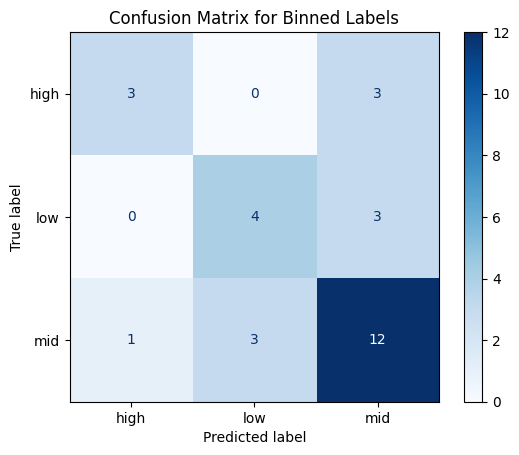

Classification Report for Binned Labels:
              precision    recall  f1-score   support

        high       0.75      0.50      0.60         6
         low       0.57      0.57      0.57         7
         mid       0.67      0.75      0.71        16

    accuracy                           0.66        29
   macro avg       0.66      0.61      0.63        29
weighted avg       0.66      0.66      0.65        29



In [24]:

# Evaluate the best model on the test set
best_model = random_search.best_estimator_  # Pull out the best model from the search
y_pred_binned = best_model.predict(X_test_binned)  # Predict on the test set
test_accuracy_binned = accuracy_score(y_test_binned, y_pred_binned)  # Calculate test accuracy
print(f"Test Accuracy of Best Model on Binned Labels: {test_accuracy_binned:.3f}")

# Display confusion matrix heatmap for evaluation
conf_matrix = confusion_matrix(y_test_binned, y_pred_binned, labels=best_model.classes_)  # Get confusion matrix
conf_matrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=best_model.classes_)  # Generate display object
conf_matrix_display.plot(cmap=plt.cm.Blues)  # Plot confusion matrix with blue color map
plt.title("Confusion Matrix for Binned Labels")
plt.show()

# Print classification report for evaluation
print("Classification Report for Binned Labels:")
print(classification_report(y_test_binned, y_pred_binned))

These reports are extremely helpful in understanding how the model operated. Firstly, the model had a 75% precision when predicting high-performing students, meaning that it was correct 75% of the time when classifying a student as a high-scorer. On the sample that it did misclassify, the student was really an average performer. Similarly, the model only had a 50% recall, meaning that it only captured 50% of actual high-performing students in the test set. When predicting, the model classified the students as average performers. This is likely due to the binning technique, with few differences between BB and BA students. To validate this hypothesis, we can view the predicted high-performing students, observing their actual true output grade. While the testing set is very small (only 6 total high-performing students), this test could still be insightful to validate the approach.

In [25]:
# Filter for students predicted as "high" performing
high_mask = (y_pred_binned == "high")  # Get the mask for high performers

# Create a DataFrame of actual vs predicted for high performers
high_predictions = pd.DataFrame({
    "Actual Grade (Binned)": y_test[high_mask].values,
    "Predicted Grade (Binned)": y_pred_binned[high_mask]
})

# Print the dataframe
pprint(high_predictions)

   Actual Grade (Binned) Predicted Grade (Binned)
0                      6                     high
1                      7                     high
2                      6                     high
3                      4                     high


From these results, we can see that the misclassified student actually received a CB grade, falling in the middle of the average performer bin. This does showcase a level of complexity or noise within the dataset, with different student performances potentially not having clear seperations. However, given this validation, we can continue with the approach. 

Now that we have the optimized model, we can extract the *feature importances* to directly expose how influential each feature was to the Random Forest prediction.

In [26]:
feature_importances = best_model.feature_importances_  # Get feature importances from the best model
feature_names = X.columns  # Get feature names from the original feature set

# Zip feature names and their corresponding importances together to sort
sorted_importances = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# Print the sorted feature importances
print("Feature Importances (sorted):")
for feature, importance in sorted_importances:
    print(f"{feature}: {importance:.4f}")
    # Early exit condition for only printing significant features
    if importance < 0.02:
        break


Feature Importances (sorted):
Course ID_7: 0.0748
Cumulative grade point average in the last semester (/4.00): 0.0746
Course ID_1: 0.0647
Father's education: 0.0430
Expected Cumulative grade point average in the graduation (/4.00): 0.0370
Mother's education: 0.0350
Flip-classroom: 0.0334
Course ID_6: 0.0299
Scholarship type: 0.0271
Number of sisters/brothers (if available): 0.0266
Course ID_3: 0.0240
Sex_1: 0.0238
Father's occupation_2: 0.0216
Sex_2: 0.0214
Weekly study hours: 0.0204
Father's occupation_4: 0.0196


For additional observations, we can map these results onto a bar chart using plotly.

In [27]:
# Create a dataframe for the feature importances for easier plotting
importance_df = pd.DataFrame({
    'Feature': [name for name, _ in sorted_importances],
    'Importance': [importance for _, importance in sorted_importances]
})

# Create a bar chart using Plotly
fig = px.bar(
    importance_df,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Feature Importances for Student Grade Prediction',
    labels={'Importance': 'Importance Score', 'Feature': 'Feature Name'},
    color='Importance',
    color_continuous_scale='Blackbody'
)

# Update layout for better readability
fig.update_layout(
    height=1500,  # Increased height to fit all feature names
    showlegend=False,
    yaxis={'categoryorder': 'total ascending'}  # Sort features by importance
)

fig.show()

This plot indicates that the individual course that each student is in is the highest indicator of output grade, as different courses may have different grading standards or difficulty levels. In addition to course differences, GPA variables had significant weights, as previous performance can be a good indicator of future performance. An additional interesting observation is that parental education and occupation have moderate importance when modeling student performance. However, other study-related behaviors show a significantly weaker influence.

Although this model could still be insightful for detecting at-risk students, it is not helpful for attempting to model the "perfect student". To account for this, we can re-train a model on a dataset that excludes fields such as the course ID and previous GPA.

In [28]:
# Define features patterns to be dropped
drop_feature_patterns = [
    "Course ID_",  # Drop course-specific features
    "Cumulative grade point average",  # Drop cumulative GPA
    "Expected Cumulative grade point average",  # Drop expected cumulative GPA
    "Flip-classroom",  # Drop flip-classroom related features, which may be more related to course\
    "Cluster"  # Drop cluster labels to avoid data leakage
]

# Determine which columns to drop based on the patterns
columns_to_drop = [col for col in hesp_df_encoded_scaled.columns if any(pattern in col for pattern in drop_feature_patterns)]

# Drop the identified columns from the encoded and scaled dataframe
hesp_df_encoded_scaled_cleaned = hesp_df_encoded_scaled.drop(columns=columns_to_drop, inplace=False)

# Print the remaining columns after dropping for validation
print(hesp_df_encoded_scaled_cleaned.columns)

Index(['Student Age', 'Scholarship type', 'Total salary if available',
       'Mother's education', 'Father's education',
       'Number of sisters/brothers (if available)', 'Weekly study hours',
       'Reading frequency (non-scientific books/journals)',
       'Reading frequency (scientific books/journals)',
       'Impact of your projects/activities on your success',
       'Attendance to classes', 'Preparation to midterm exams 2',
       'Taking notes in classes', 'Listening in classes',
       'Discussion improves my interest and success in the course',
       'OUTPUT Grade', 'Sex_1', 'Sex_2', 'Graduated high-school type_1',
       'Graduated high-school type_2', 'Graduated high-school type_3',
       'Additional work_1', 'Additional work_2',
       'Regular artistic or sports activity_1',
       'Regular artistic or sports activity_2', 'Do you have a partner_1',
       'Do you have a partner_2', 'Transportation to the university_1',
       'Transportation to the university_2',
  

Now that we have a new dataframe, we can re-do all previous steps to get a new optimal model and examine the feature importances.

In [ ]:
# separate features and target variable again with cleaned data
X_cleaned = hesp_df_encoded_scaled_cleaned.drop([TARGET_COLUMN_NAME], axis=1, errors='ignore')
# y will remain the same as before since target variable is unchanged

# Split into training and testing sets with cleaned features
X_train_binned_cleaned, X_test_binned_cleaned, y_train_binned, y_test_binned = train_test_split(X_cleaned, y_binned, test_size=0.2, random_state=42)

# Re-run the randomized search with cleaned features
random_search_cleaned = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,  # Using previous hyperparameter grid
    n_iter=250,  # Number of parameter settings that are sampled
    scoring='accuracy',  # Score on accuracy
    cv=5,  # 5-Fold Cross-Validation
    verbose=0,  # Disable verbose output for cleaner reporting
    random_state=42,
    n_jobs=-1  # Use all available cores for training, increasing overall speed
)

# Fit the Randomized Search to the cleaned dataset
random_search_cleaned.fit(X_train_binned_cleaned, y_train_binned)  #Using the binned labels for classification

# Print the basic results
print(f"Best Accuracy (Cleaned): {random_search_cleaned.best_score_} with hyperparameters: {random_search_cleaned.best_params_}")

# Evaluate the best model on the test set
best_model_cleaned = random_search_cleaned.best_estimator_  # Pull out the best model from the search
y_pred_binned_cleaned = best_model_cleaned.predict(X_test_binned_cleaned)  # Predict on the test set
test_accuracy_binned_cleaned = accuracy_score(y_test_binned, y_pred_binned_cleaned)  # Calculate test accuracy
print(f"Test Accuracy of Best Model on Binned Labels (Cleaned): {test_accuracy_binned_cleaned:.3f}")

# Pull out feature importances from the cleaned best model
feature_importances_cleaned = best_model_cleaned.feature_importances_
feature_names_cleaned = X_cleaned.columns

# Zip feature names and their corresponding importances together to sort
sorted_importances_cleaned = sorted(zip(feature_names_cleaned, feature_importances_cleaned), key=lambda x: x[1], reverse=True)

# Place feature importances for the cleaned model into a pandas dataframe for easier plotting
importance_df_cleaned = pd.DataFrame({
    'Feature': [name for name, _ in sorted_importances_cleaned],
    'Importance': [importance for _, importance in sorted_importances_cleaned]
})

# Create a bar chart using Plotly
fig = px.bar(
    importance_df_cleaned,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Feature Importances for Student Grade Prediction (Cleaned)',
    labels={'Importance': 'Importance Score', 'Feature': 'Feature Name'},
    color='Importance',
    color_continuous_scale='Blackbody'
)

# Update layout for better readability
fig.update_layout(
    height=1500,  # Increased height to fit all feature names
    showlegend=False,
    yaxis={'categoryorder': 'total ascending'}  # Sort features by importance
)
fig.show()

Best Accuracy (Cleaned): 0.4818840579710145 with hyperparameters: {'n_estimators': 50, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_depth': 44, 'bootstrap': False}
Test Accuracy of Best Model on Binned Labels (Cleaned): 0.586


From this new analysis, we can see that the model performed at around 58% on an independent test, with the most significant features being parent's education, student age, reading frequency, weekly studying hours, number of brothers/sisters (surprisingly), and whether the student reported listening in class. Surprisingly, these results do not indicate that reported preparation for midterm exams had a significant impact on output grade classification.

For a more reliable measurement of feature importance, we can use a *Permutation Importance* analysis to measure what happens when we shuffle each feature, effectively giving us better insights on model performance. 

In [30]:
from sklearn.inspection import permutation_importance  # For permutation importance analysis

# Calculate permutation importances for the cleaned best model using test set, with increases n_repeats for stability
permutation_importance_results = permutation_importance(best_model_cleaned, X_test_binned_cleaned, y_test_binned, n_repeats=50, random_state=42, n_jobs=-1)

# Sort permutation importances
sorted_permutation_importance_results = sorted(zip(X_cleaned.columns, permutation_importance_results.importances_mean), key=lambda x: x[1], reverse=True)

# Pull out the top 10 most important features based on permutation importance
top_10_permutation_importances = sorted_permutation_importance_results[:10]

# Print the sorted permutation importances
print("Permutation Importances (sorted):")
for feature, importance in top_10_permutation_importances:
    print(f"{feature}: {importance:.4f}")
    
# Plot permutation importances using Plotly
importance_perm_df = pd.DataFrame({
    'Feature': [name for name, _ in top_10_permutation_importances],
    'Importance': [importance for _, importance in top_10_permutation_importances]
})
fig = px.bar(
    importance_perm_df,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 10 Permutation Importances for Student Grade Prediction (Cleaned)',
    labels={'Importance': 'Importance Score', 'Feature': 'Feature Name'},
    color='Importance',
    color_continuous_scale='Blackbody'
)
fig.update_layout(
    height=600,
    showlegend=False,
    yaxis={'categoryorder': 'total ascending'}  # Sort features by importance
)
fig.show()

Permutation Importances (sorted):
Student Age: 0.0890
Weekly study hours: 0.0476
Mother's education: 0.0428
Father's education: 0.0400
Number of sisters/brothers (if available): 0.0386
Mother's occupation_4: 0.0379
Sex_2: 0.0372
Total salary if available: 0.0324
Father's occupation_2: 0.0207
Accomodation type in Cyprus_1: 0.0193


From the results of the permutation importance tests, we can see that factors such as student age and weekly study hours are among the top most important features, with parent's education, number of sisters/brothers, and salary being other significant indicators.

While the permutation importance test is very good at informing us on what features are actually important, it does not provide insights on **what** values lead to higher performance. In order to determine this (not that we have the most significant features), we can use the *SHAP* (SHapley Additive exPlanations) technique. This technique uses game theory principles, adding and subtracting from baseline feature values to determine how each value plays into a certain prediction.

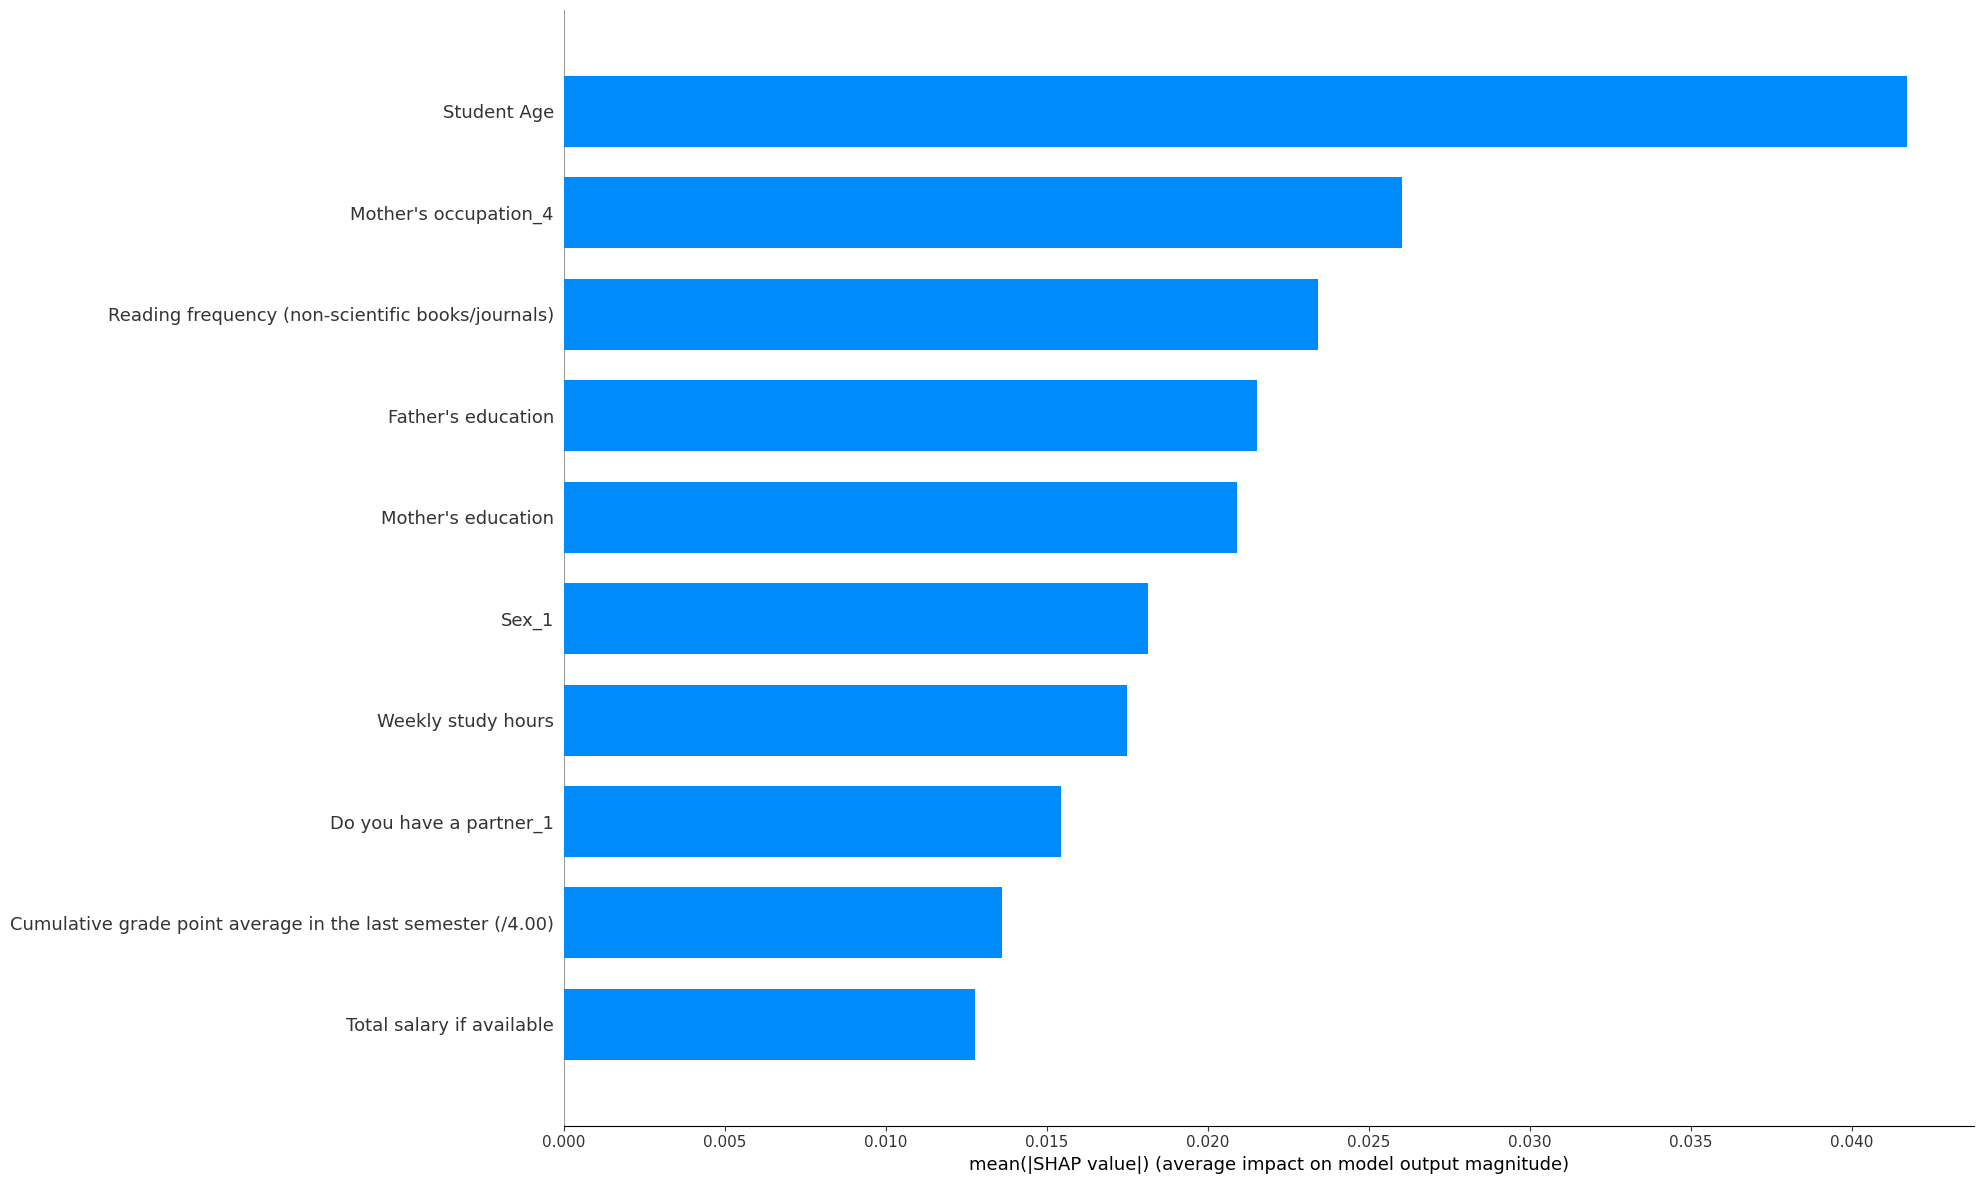

In [52]:
import shap  # Import SHAP library for model interpretability
import numpy as np  # Numerical operations

# Pull out the most significant features based on previous importance analysis
top_10_feature_names = [name for name, _ in top_10_permutation_importances]  # Extract the top 10 feature names from permutation importance results
X_top_10 = X_cleaned[top_10_feature_names]  # Create a new dataframe with only the top 10 most important features

# Reduce background size of the training data for SHAP analysis to speed up computation
background = shap.sample(X_train_binned_cleaned, 50, random_state=42)

# Create SHAP explainer using the binned and cleaned training data
explainer = shap.TreeExplainer(best_model_cleaned)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary plot for feature importance
shap.summary_plot(shap_values[2], X_test, max_display=10, plot_type="bar", plot_size=(20, 12), show=True)  # Show only top 10 features for high performers

To more clearly see the "optimal" values for high performing students, we can construct dependence plots for each feature.

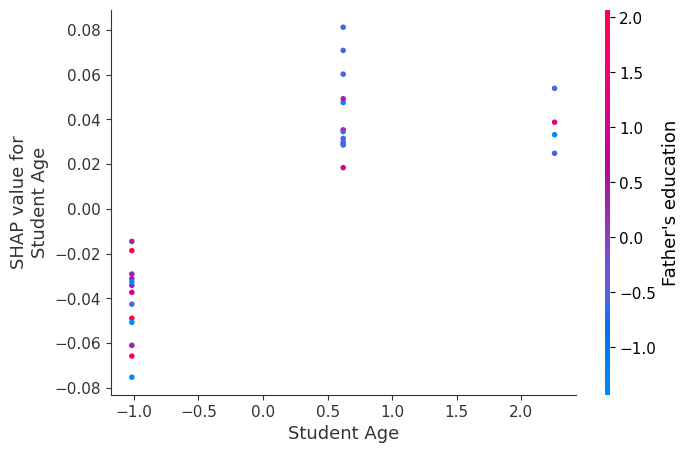

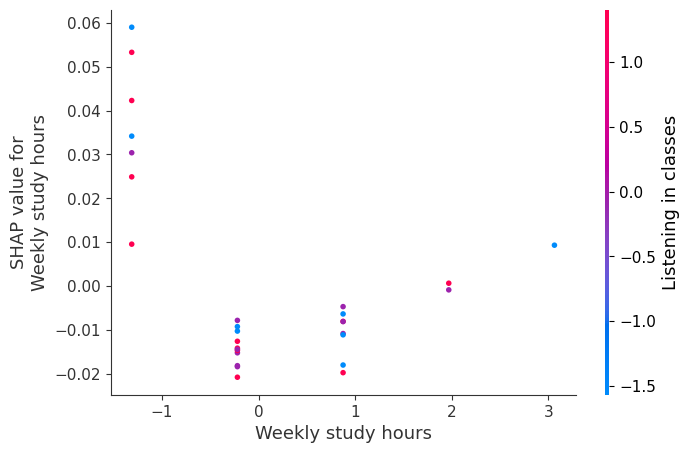

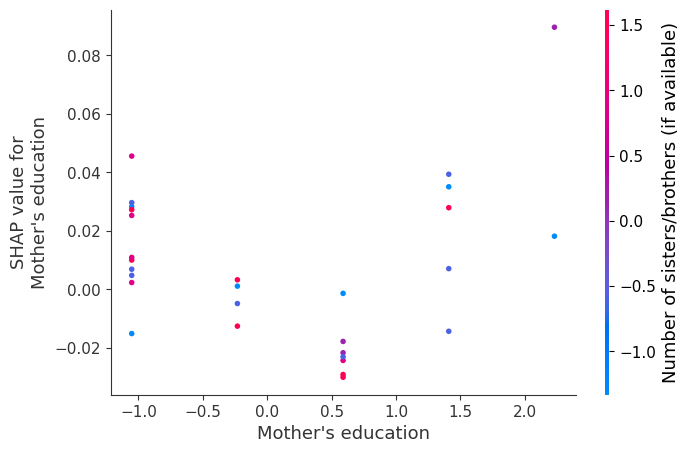

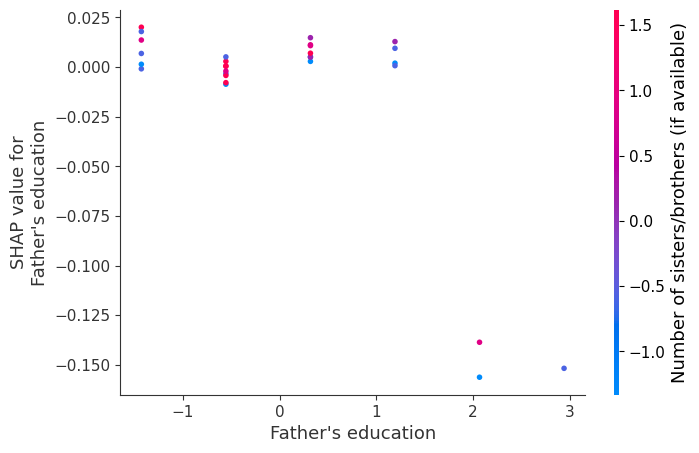

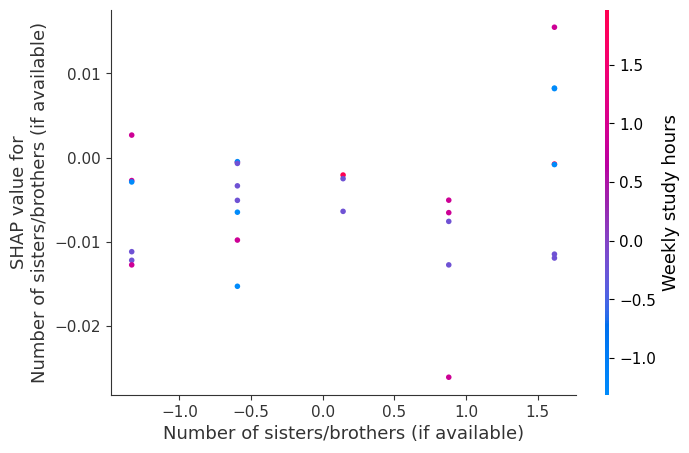

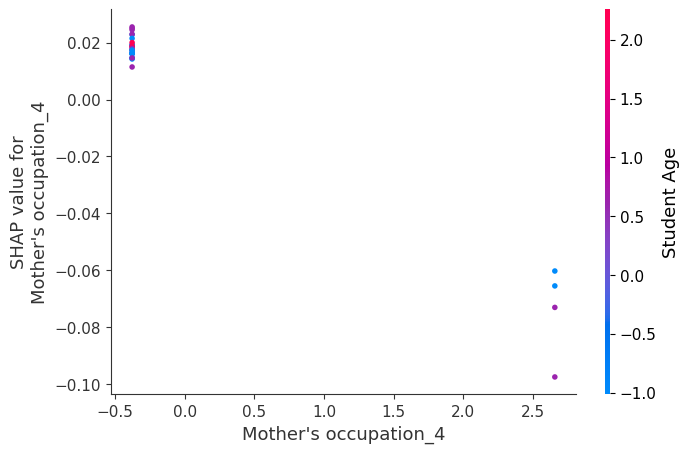

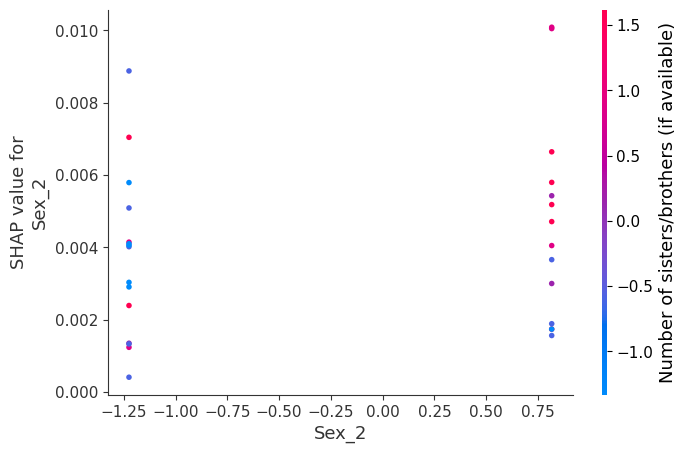

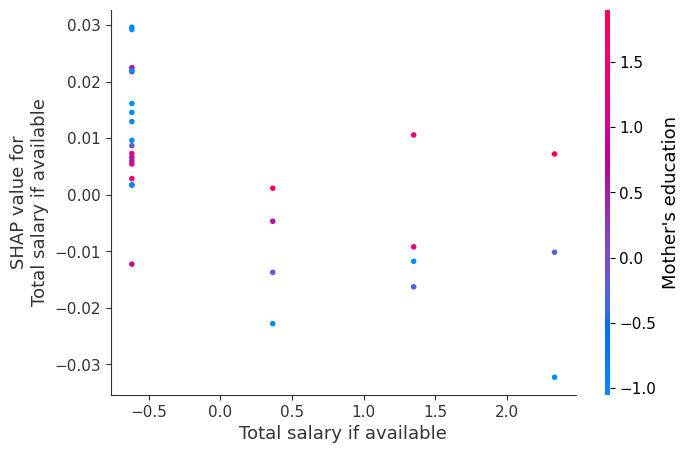

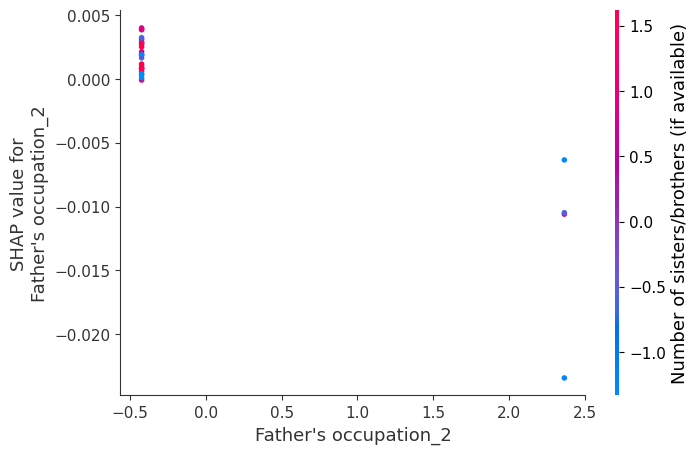

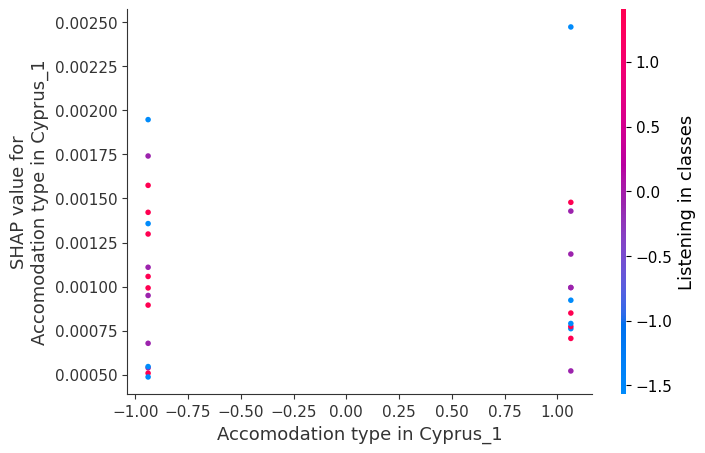

In [53]:
for feature in top_10_feature_names:
    shap.dependence_plot(feature, shap_values[2], X_test, show=True)  # Show dependence plot for each top feature

From these results, we can finally model the "perfect student". For each of these plots, the left y axis represents the "SHAP value", which is essentially the confidence that the model has when predicting high performing students. Negative SHAP values indicate that the model would be less confident in classifying a student as a high performer, while positive SHAP values indicate more confidence.

Given this, the takeaways of model confidence from each plot is as follows:

- Student Age - Younger students warrant lower confidence of being a high performer, while older students yield higher confidence
- Weekly Study Hours - Lower studying hours and higher studying hours indicate high confidence, while moderate study hours indicate lower confidence. This could point to individuals with lower studying hours being naturally strong or efficient learners, while higher studying hours indicate commitment.
- Mother's Education - Confidence has a positive relationship with level of education, however not too influential.
- Father's Education- Confidence drops when father's education is very high (MS/PHD).
- Number of Siblings - Having more siblings slightly reduces the confidence for being a high performer.
- Mother's Occupation (4) - Confidence decreases when mother is in the private sector.
- Sex (2) - There is little effect on gender when predicting academic performance.
- Total Salary - Students who earn less per month are estimated typically better performers, suggesting that students who work more may be potentially lower performers.
- Father's Occupation (2) - Confidence increases when father is in the government sector, although not very significantly.
- Accommodation Type (Cyprus 1) - Living in rental housing is very mildly beneficial to confidence.

Therefore, the **"model student"** is older (22-25), has very low or very high study hours, has parents with stable jobs (not in the private sector), has no siblings or only one sibling, works less, and has a mother with high education.

### 3. Social Indicators to Class Attendance

The third and final question focuses on correlations to social indicators and class attendance. 

For this investigation, we can take the simple approach of observing the correlation table among all raw social attributes and class attendance. The first step that we must take to accomplish this is to pull out the specific features and target (attendance).

In [60]:
ATTENDANCE_TARGET_COLUMN_NAME = 'Attendance to classes'  # Define attendance target column name

social_indicators_hesp_df = hesp_df_raw.iloc[:, :15]  # Use the first 15 attributes (as defined in documentation) for social indicators analysis
attendance_target = hesp_df_raw[ATTENDANCE_TARGET_COLUMN_NAME]  # Separate attendance target variable

# Validate the social indicators dataframe
print(social_indicators_hesp_df.shape)

(145, 15)


Now that we have the proper data, we can compute the correlation. We will be finding the *Spearman* correlation as it handles orginal categorical encodings better.

In [65]:
# Calculate correlations with attendance target
attendance_correlations = social_indicators_hesp_df.corrwith(attendance_target, method="spearman")

# Convert to a sorted dataframe for better readability
attendance_correlations_df = attendance_correlations.sort_values(ascending=False).reset_index()

attendance_correlations_df  # Display the correlations dataframe

,index,0
0,Total salary if available,0.187912
1,Do you have a partner,0.154225
2,Regular artistic or sports activity,0.098693
3,Father's education,0.081518
4,Student Age,0.059299
5,Parental status,0.032292
6,Additional work,0.028198
7,Number of sisters/brothers (if available),0.020944
8,Graduated high-school type,-0.034793
9,Transportation to the university,-0.051942


For a more intuitive visualization, we can plot the absolute values onto a bar graph to see the overall impact of each feature.

In [72]:
# Get the absolute correlation values
attendance_correlations_df["abs_correlation"] = attendance_correlations_df["correlation"].abs()

# Sort by absolute correlation strength
attendance_correlations_df = attendance_correlations_df.sort_values(
    "abs_correlation", ascending=False
)

# Plot absolute correlations using a color scale for strength
fig = px.bar(
    attendance_correlations_df,
    x="feature",
    y="abs_correlation",
    color="abs_correlation",
    color_continuous_scale="algae",
    title="Absolute Spearman Correlations with Class Attendance",
    labels={"feature": "Social Indicator", "abs_correlation": "|Correlation|"},
    hover_data={"correlation":":.3f", "abs_correlation":":.3f"},
)
fig.update_layout(
    xaxis_tickangle=-45,
    bargap=0.25,
    coloraxis_colorbar_title="|corr|",
    xaxis={
        "categoryorder": "array",
        "categoryarray": attendance_correlations_df["feature"],
    },
)
fig.show()

As we can see from the results, the largest correlation in attendance among the social factors is total monthly salary, suggesting that those who work more may be more inclined to miss class. Having a partner has the second highest correlation, followed by factors such as scholarship type (negative correlation), accommodation type, and whether the student is involved in other artistic or sports activities. However, it is important to note that these correlations are fairly small, showing that all correlations are weak.

## Conclusion

The Higher Education Students Performance dataset combines behavioral, academic, and socio-economic attributes with recorded class attendance, giving us a practical lens to profile students and explore drivers of participation.

Question 1 (profiles and clustering): We observe coherent student profiles with clear differences across key indicators, suggesting actionable segments for support strategies. Future potential directions include improving cluster stability, comparing different distance functions/algorithms, and checking generalization across terms or institutions (given more data).
Question 2 (modeling the "perfect student"): A concise subset of variables consistently surfaces as most predictive of attendance-related outcomes, pointing to feasible intervention levers. Future potential directions include using different types of models and exploring more per-course subsets.
Question 3 (social indicators and attendance): Absolute Spearman correlations show modest but meaningful relationships between several social attributes and attendance, helping prioritize what to monitor. Future directions could include focus on using different correlation algorithms and development of a model to predict attendance levels.

Additionally, it is substantial to note that the data is small in size and self-reported, presenting opportunity for noise or non-generalizable patterns. Given a larger sample of data, further and stronger analysis could be done to generalize the hypotheses presented in this analysis.

## Annotated Bibliography

<!-- Cited the ORIGINAL works for each one, I believe this is how it would be on a research paper. At the bottom in another comment, I have the versions I used. -->

- Yilmaz, N., & Şekeroğlu, B. (2019). *Higher Education Students Performance Evaluation* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C51G82  
  *Annotation:* This is the primary dataset used throughout the notebook (UCI ID 856), providing demographic, family, and educational-habit variables alongside outcomes like course grade and class attendance.

- Spearman, C. (1904). The proof and measurement of association between two things. *The American Journal of Psychology, 15*(1), 72–101.  
  *Annotation:* Used to compute Spearman rank correlations when relating categorical-encoded social indicators to attendance; this is more robust than Pearson correlation when relationships are monotonic but not strictly linear.

- Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics, 18*(1), 50–60.  
  *Annotation:* Applied for non-parametric significance testing between cluster groups (Mann–Whitney U), avoiding normality assumptions and making it suitable for ordinal/categorical encodings.

- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). A density-based algorithm for discovering clusters in large spatial databases with noise. In *Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD’96)* (pp. 226–231).  
  *Annotation:* Reference for DBSCAN, used as an alternative clustering approach that can label noise/outliers and does not require specifying the number of clusters in advance.

- Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research, 13*, 281–305.  
  *Annotation:* Motivates the notebook’s randomized hyperparameter search approach (via randomized search) as an efficient alternative to exhaustive grid search, especially when only a few hyperparameters strongly matter.

- Altmann, A., Toloşi, L., Sander, O., & Lengauer, T. (2010). Permutation importance: A corrected feature importance measure. *Bioinformatics, 26*(10), 1340–1347.  
  *Annotation:* Supports the permutation importance procedure used to quantify how much shuffling each feature degrades model performance, producing a more model-agnostic view of importance than built-in impurity scores.

- Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In *Advances in Neural Information Processing Systems* (NeurIPS).  
  *Annotation:* Introduces SHAP values, which the notebook uses for post-hoc explainability (summary and dependence plots) to interpret how top features push predictions toward higher performance classes.

<!-- Actual Sources:
- Scikit-learn Developers. *Spearman and Pearson Correlation Metrics – sklearn.metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html  
  *Annotation:* Documentation outlining correlation metrics and their use cases, supporting the selection of Spearman correlation for ordinal-encoded social indicators.

- Scikit-learn Developers. *RandomizedSearchCV – Hyperparameter Optimization*. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html  
  *Annotation:* Official reference for randomized hyperparameter search, used to tune Random Forest models efficiently compared to exhaustive grid search.

- Scikit-learn Developers. *Random Forest Classifier*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html  
  *Annotation:* Source for the Random Forest implementation used in the notebook, detailing parameters such as tree depth, estimators, and class balancing strategies.

- Scikit-learn Developers. *Permutation Importance*. https://scikit-learn.org/stable/modules/permutation_importance.html  
  *Annotation:* Documentation for model-agnostic permutation importance used to evaluate feature contributions by measuring prediction degradation when feature values are shuffled.

- SHAP Developers. *SHAP Documentation – TreeExplainer, Summary Plots, Dependence Plots*. https://shap.readthedocs.io/en/latest/  
  *Annotation:* Primary resource explaining TreeSHAP’s theory and implementation, used to generate global and local interpretability plots describing how features influence classification outcomes.

- Scikit-learn Developers. *Mann–Whitney U and Nonparametric Tests (scipy.stats)*. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html  
  *Annotation:* Documentation for the non-parametric test used when comparing distributions between attendance groups without assuming normality.

-->


## Appendix

N/A